In [ ]:
# The first part of the notebook shows how to compute spatial chaos scores for each ion in the dataset using the compute_spatial_chaos_scores function.
# This function calculates the spatial chaos score for each ion based on the spatial distribution of its intensities across the tissue sample.
# Then we apply a filter to keep only the ions that have a mean spatial chaos score above a certain threshold (e.g., 0.4) across all samples.
# We then compute_spatial_chaos_fold_change to calculate the fold change of spatial chaos scores between the "interaction" and "control" conditions for each ion, and we can filter the ions based on their fold change and log2 fold change to identify the most differentially abundant ions with significant changes in spatial chaos between the conditions.
# We then cluster the ions based on their graph of mass differences and colocalization. 

In [1]:
import deltamsi
from deltamsi.core.msicube import MSICube
import matplotlib.pyplot as plt

In [ ]:
# replace "/directory/containing/imzml/data" with the actual path to the directory containing your imzML data. The directory should contain the imzML file and the corresponding .ibd file for the dataset you want to analyze. Make sure to adjust the path according to your file system and dataset organization.
# imzml files can be downloaded from the METASPACE platform (https://metaspace2020.eu/) ID  ds=2026-04-16_00h51m31s . Once you have the imzML files, you can use the code below to load the data into an MSICube object and perform the analysis as described in the notebook.


In [ ]:
# compute mean spectra for each sample and globally, then pick peaks on the global mean spectrum.
cube = MSICube(data_directory="/directory/containing/imzml/data")
cube.compute_mean_spectra(scope = "samples" ,mode="centroid",mass_accuracy_ppm=None, tolerance_da =0.0005 , min_mz=100.0, max_mz=1200, binning_p=0.0001 )
cube.compute_mean_spectra(scope = "global",tic_normalize=False)
cube.pick_peaks(topn=3000,binning_p=0.0001,distance_ppm=10)

INFO: MSICube initialized with 2 samples found.
INFO: Calculating mean spectrum for: interaction_fer (Mode: centroid)
INFO: Calculating mean spectrum for: interaction (Mode: centroid)
INFO: Mean spectra calculated and stored.
INFO: Computing global mean spectrum...
INFO: Global mean spectrum calculated and stored in adata.uns['mean_spectrum_global'].
INFO: Starting peak picking on the global mean spectrum.
INFO: Peak picking finished. 3000 mz selected.
INFO: Selected mz values stored in adata.var and adata.uns['peak_picking_options'].


In [ ]:
# extract the ion images for the picked peaks, using a tolerance of 10 ppm for matching the m/z values in the spectra to the picked peaks. This step will create a new variable in the adata.var DataFrame with the key "mz_XXX" for each picked peak, where XXX is the m/z value of the peak. The ion images will be stored as arrays in this variable, and can be accessed and visualized using the appropriate functions in the MSICube class.
cube.extract_matrix(tol_ppm=10)

INFO: Starting extraction of peak intensity matrix (X) for all samples.
INFO: Extracting matrix for sample: interaction
INFO: Extracting matrix for sample: interaction_fer
INFO: Concatenating data from all samples...
INFO: Extraction complete. Final shape: (5700, 3000) (Pixels x Peaks). Data stored in adata.X, adata.obsm['spatial'], adata.obs['sample'].


In [ ]:
# save the MSICube object to a file for later use. This will allow you to reload the object and access the computed mean spectra, picked peaks, and extracted ion images without having to repeat the computationally intensive steps of loading the data and processing it. You can specify the file path and name for saving the MSICube object, and it will be saved in a format that can be easily reloaded using the appropriate function in the MSICube class.
cube.save()

INFO: AnnData saved to /home/rlarocca20/msi_data/interaction/adata.h5ad (format=h5ad).


'/home/rlarocca20/msi_data/interaction/adata.h5ad'

In [ ]:
from deltamsi import MSICube
import numpy as np

cube = MSICube("/directory/containing/imzml/data")
cube.load()

INFO: MSICube initialized with 2 samples found.
INFO: AnnData loaded from /home/rlarocca20/msi_data/interaction/adata.h5ad (format=h5ad).


AnnData object with n_obs × n_vars = 5700 × 3000
    obs: 'sample'
    var: 'mz'
    uns: 'matrix_extraction_options', 'mean_spectra', 'mean_spectra_options', 'mean_spectra_samples', 'mean_spectrum_global', 'mean_spectrum_global_options', 'peak_picking_options'
    obsm: 'spatial'
    layers: 'RAW'

In [ ]:
# clip the intensities below 10000 and move them to a new layer called "clip", then compute the spatial chaos scores on the "clip" layer.
cube.clip_or_mask_intensities(low=10000, layer = "RAW", low_action="move", output_layer="clip")
cube.compute_spatial_chaos_scores(obsm_key="spatial", sample_key="sample",layer="clip")

array([[0.54680729, 0.41686808],
       [0.63024295, 0.64983713],
       [0.84095366, 0.78262214],
       ...,
       [0.68794573, 0.42837226],
       [0.53047327, 0.50612028],
       [0.63291732, 0.20561798]])

In [ ]:
# filter the ions based on their spatial chaos scores (e.g., keep ions with mean chaos score >= 0.4)
# spatial chaos scores: shape (n_vars, n_samples)

chaos = cube.adata.varm["spatial_chaos"]

mean_chaos = np.nanmax(chaos, axis=1)
keep_mask = mean_chaos >= 0.4

cube.adata = cube.adata[:, keep_mask].copy()

In [ ]:
# match the m/z values of the picked peaks to known m/z values of siderophores,
# using a tolerance of 5 ppm for matching. 
# This step will add annotations to the adata.var DataFrame for the matched peaks, with the annotation "Desferrioxamine" for the peaks that match the m/z values of Desferrioxamine, 
# and "Scabichelin" for the peaks that match the m/z value of Scabichelin. The annotations will be stored in a new column called "known", and can be accessed and visualized using the appropriate functions in the MSICube class.
cube.match_mzs_to_var_simple(mzs=[498.266],mode="tolerance",tol=5,annotation="unknown siderophore",annotation_col="known",multi_write = "append")
cube.match_mzs_to_var_simple(mzs=[583.344,639.312],mode="tolerance",tol=5,annotation="Desferrioxamine",annotation_col="known",multi_write = "append")
cube.match_mzs_to_var_simple(mzs=[670.351],mode="tolerance",tol=5,annotation="Scabichelin",annotation_col="known",multi_write = "append")

,query_mz,n_matches,match_pos,match_mz,err_da,err_ppm,tol_da,tol_unit,tol_value
0,670.351,1,[1309],[670.3511000189336],[0.00010001893360822578],[0.14920382547087388],0.003352,ppm,5.0


In [19]:
cube.adata.var[cube.adata.var["known"].notna()]

,mz,known
feature_id,,
mz_605_498.2658,498.2658,unknown siderophore
mz_919_583.3438,583.3438,Desferrioxamine
mz_1211_639.3125,639.3125,Desferrioxamine
mz_1350_670.3511,670.3511,Scabichelin


In [ ]:
# compute fold change of spatial chaos scores between the "interaction" and "control" samples,
# then add a new variable in adata.var called "FC" with value "1" for ions with fold change > 2 and "0" for ions with fold change <= 2.
obs = cube.adata.obs
obs["condition"] = "control"
obs.loc[obs["sample"] == "interaction", "condition"] = "interaction"

fc_results = cube.compute_spatial_chaos_fold_change(
    groupby="condition",
    control_label="control",
    interaction_label="interaction"
)

mask = fc_results["FC_S"] > 2

cube.adata.var["FC"] = np.where(mask, "1", "0")


In [25]:
cube.adata.var[cube.adata.var["known"].notna()]

,mz,known,spatial_chaos_fold_change_control_max,spatial_chaos_fold_change_interaction_max,spatial_chaos_fold_change_FC_S,FC
feature_id,,,,,,
mz_605_498.2658,498.2658,unknown siderophore,0.195114,0.897933,4.602093,1
mz_919_583.3438,583.3438,Desferrioxamine,0.153066,0.951835,6.218462,1
mz_1211_639.3125,639.3125,Desferrioxamine,0.099893,0.959216,9.602475,1
mz_1350_670.3511,670.3511,Scabichelin,0.043172,0.969217,22.450222,1


In [14]:
# Subset AnnData along vars (ions)
cube.adata = cube.adata[:, mask].copy()

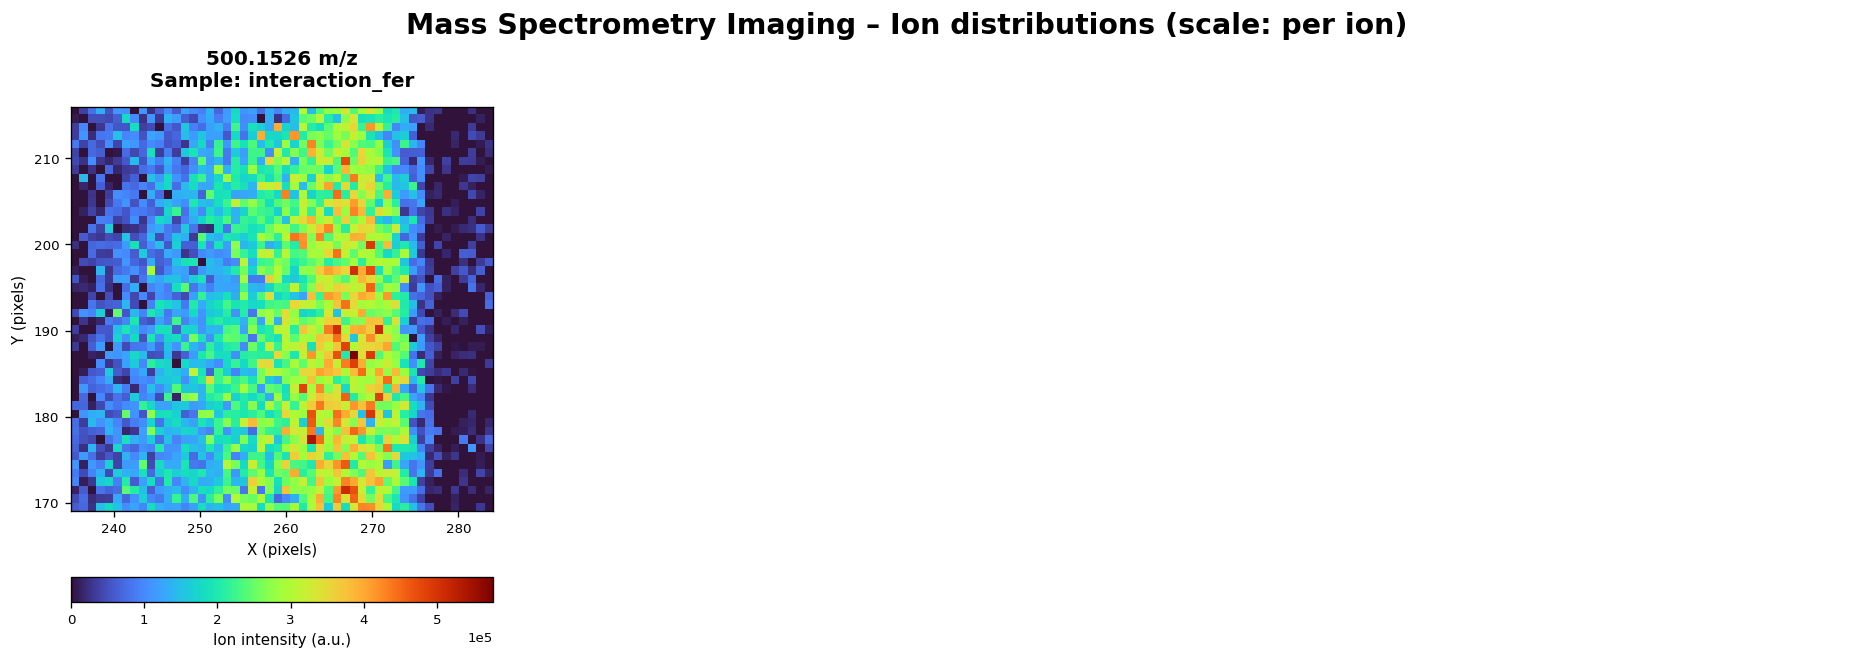

In [ ]:
# visualize the ion images closest to  m/z 500 for the "interaction_fer" sample, using per ion scaling for the images. 
# This step will create ion images for the specified m/z values and sample, and display them using the appropriate visualization functions in the MSICube class.
cube.plot_ion_images(mz=[500],samples="interaction_fer", scale_mode="per_ion")

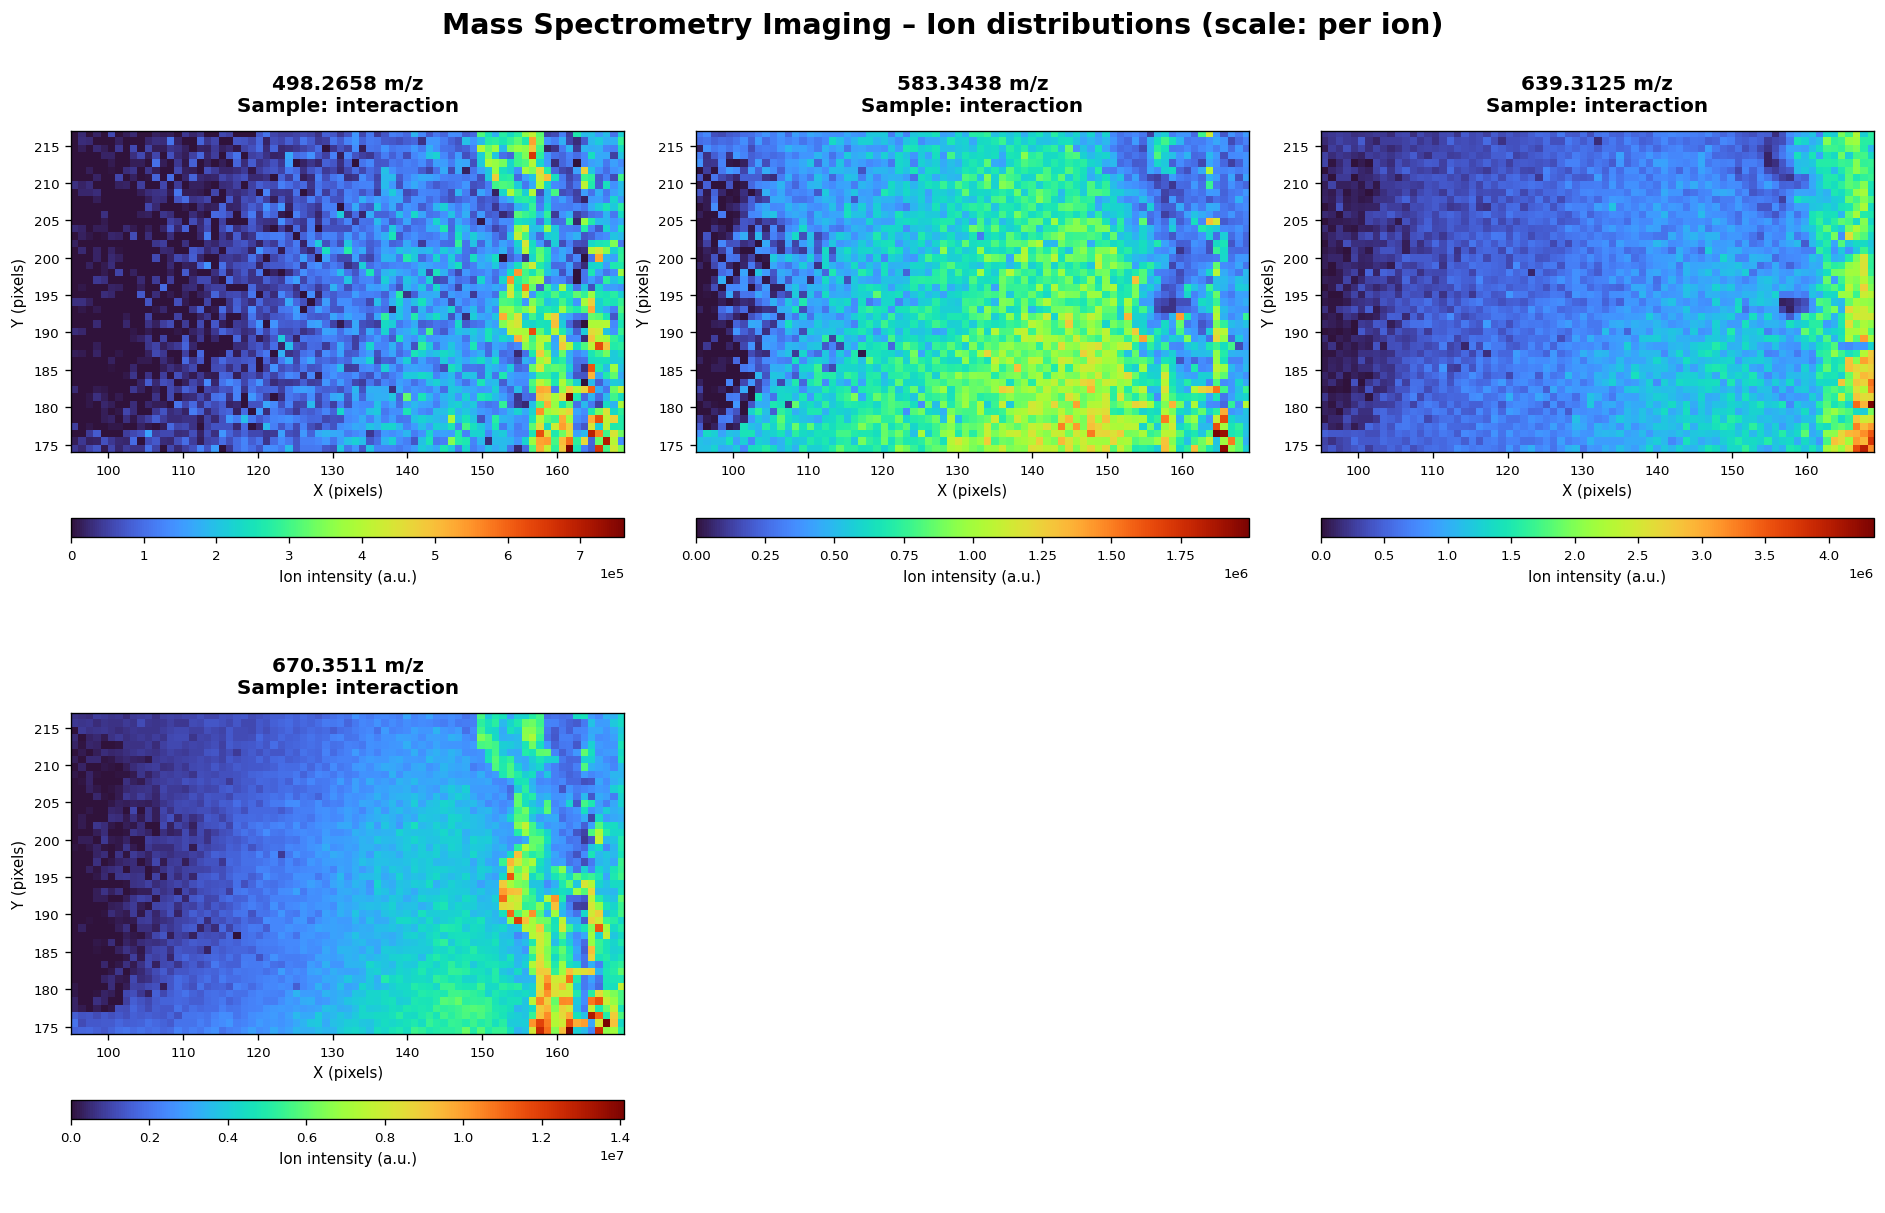

In [46]:
cube.plot_ion_images(mz=[498.266 ,583.344,639.312,670.351],samples="interaction", scale_mode="per_ion")

(<Figure size 1260x630 with 1 Axes>,
 [<Axes: title={'center': 'Kendrick by FAMILY'}, xlabel='Kendrick mass (base CH2)', ylabel='KMD (fraction)'>],
             mz  cluster family  kendrick_mass  kmd_fraction  kmd_defect
 0     161.7055        0   <NA>     161.524933      0.524937         NaN
 1     194.4517        0   <NA>     194.234573      0.234573         NaN
 2     199.7765        0   <NA>     199.553421      0.553427         NaN
 3     213.1087        0   <NA>     212.870743      0.870740         NaN
 4     223.4481        0   <NA>     223.198593      0.198595         NaN
 ..         ...      ...    ...            ...           ...         ...
 483  1189.4901        0   <NA>    1188.161865      0.161899         NaN
 484  1189.5121        0   <NA>    1188.183838      0.183875         NaN
 485  1193.5015        0   <NA>    1192.168823      0.168820         NaN
 486  1194.4860        0   <NA>    1193.152222      0.152221         NaN
 487  1198.5867        0   <NA>    1197.248291   

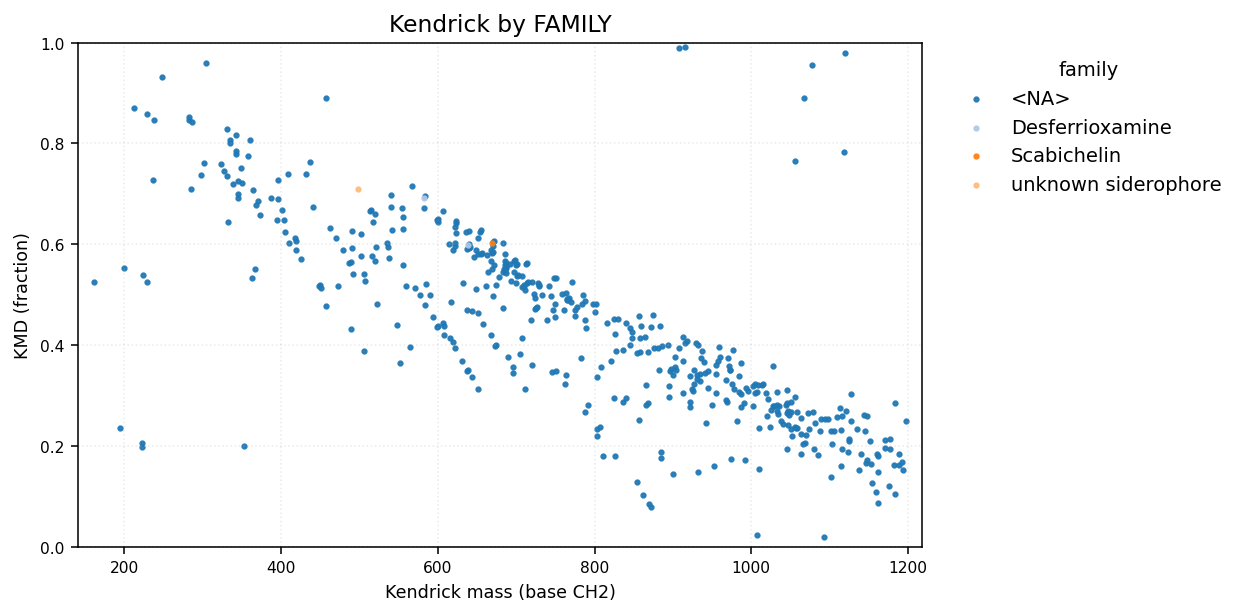

In [ ]:
# visualize the Kendrick plot for the ions with annotations in the "known" column, using point size of 5 and displaying all ions in a single panel. 
# This step will create a Kendrick plot where the x-axis represents the Kendrick mass defect and the y-axis represents the Kendrick mass, 
# with points colored according to the annotations in the "known" column.
cube.plot_kendrick( label_col="known",point_size = 5,two_panels=False)

In [ ]:
# load the mass difference database and append some additional mass differences to it.
# the mass difference database is a csv file with three columns: "delta_da", "label", and "score". The "delta_da" column contains the mass differences
# in daltons, the "label" column contains the annotation for the mass difference, and the "score" column contains a score for the mass difference (e.g., based on its frequency in a reference database). You can replace the additional mass differences with your own values and labels as needed.
# Note: the mass difference database is used for annotating the mass differences between the cluster centers and the picked peaks, so make sure to include the relevant mass differences for your dataset and analysis goals.
# CCBF_200_L1_massweighted is a mass difference database that contains the most common mass differences between metabolites from the COCONUT database, weighted by their frequency in the database. You can use this database as a starting point for annotating the mass differences in your dataset, and then add any additional mass differences that are relevant to your analysis.


import pandas as pd
mass_diff = pd.read_csv("./data/CCBF_200_L1_massweighted.csv")
mass_diffdb = mass_diff[["delta_da","label","score"]].copy()
rows = []
rows.append({"delta_da": 1.00335, "label": "13C-12C", "score": 1})
rows.append({"delta_da": 2.00670, "label": "13C2-12C2", "score": 1})
rows.append({"delta_da": 2.00425, "label": "18O-16O", "score": 1})
rows.append({"delta_da": 15.97394, "label": "K-Na", "score": 1})
rows.append({"delta_da": 21.98194, "label": "Na-H", "score": 1})
rows.append({"delta_da": 37.95588, "label": "K-H", "score": 1})
rows.append({"delta_da": 189.04259, "label": "C10H7NO3", "score": 1})

mass_diffdb  = pd.concat([mass_diffdb , pd.DataFrame(rows)], ignore_index=True)

In [ ]:
# compute the cosine similarity between the ion images in the "im_process" layer, excluding self-colocalization, and store the results in varp under the key "ion_cosine".
from deltamsi.processing.colocalization import CosineColocParams
S = cube.compute_cosine_colocalization(params=CosineColocParams(mode="dense", include_self=False, store_varp_key="ion_cosine"))

In [ ]:
# cluster the ions based on their mass differences  and their cosine colocalization scores, keeping only the ions with a mean cosine similarity above 0.5, and store the cluster labels in var under the key "mass_cluster". The mass differences between the cluster centers and the picked peaks are annotated using the mass difference database loaded earlier.
# Note: the clustering method used here is based on a graph of mass differences, where the edges between the ions are defined based on the mass differences between their m/z values and the mass differences in the mass difference database. The weights of the edges are defined based on the scores in the mass difference database and the cosine colocalization scores between the ions. You can adjust the parameters of the clustering method (e.g., tolerance for mass differences, weighting scheme for edges, clustering resolution) to better suit your dataset and analysis goals.
from deltamsi.params.options import (MassClusteringOptions,)
options_clustering = MassClusteringOptions(tol_da=0.0005, tol_ppm=None, edge_max_delta_m=200, delta_col='delta_da', score_col='score', label_col='label', resolution=0.1, weight_transform='inv1p', weight_kwargs={}, knn_k=100, knn_mode='union', return_graph=False)
cube.cluster_masses(candidates_df=mass_diffdb,options= options_clustering,keep_mask = S >0.5)
#cube.cluster_masses(candidates_df=mass_diffdb,options= options_clustering)

INFO: Starting clustering on 488 masses (Resolution: 0.1, Method: candidates)...
INFO: Clustering complete: 45 clusters found.


(<Figure size 1260x630 with 2 Axes>,
 array([<Axes: title={'center': 'Kendrick by CLUSTER'}, xlabel='Kendrick mass (base CH2)', ylabel='KMD (fraction)'>,
        <Axes: title={'center': 'Kendrick by FAMILY'}, xlabel='Kendrick mass (base CH2)'>],
       dtype=object),
             mz  cluster family  kendrick_mass  kmd_fraction  kmd_defect
 0     161.7055       -1   <NA>     161.524933      0.524937         NaN
 1     194.4517       -1   <NA>     194.234573      0.234573         NaN
 2     199.7765       -1   <NA>     199.553421      0.553427         NaN
 3     213.1087       -1   <NA>     212.870743      0.870740         NaN
 4     223.4481       -1   <NA>     223.198593      0.198595         NaN
 ..         ...      ...    ...            ...           ...         ...
 364  1189.4901       -1   <NA>    1188.161865      0.161899         NaN
 365  1189.5121       -1   <NA>    1188.183838      0.183875         NaN
 366  1193.5015       -1   <NA>    1192.168823      0.168820         NaN
 3

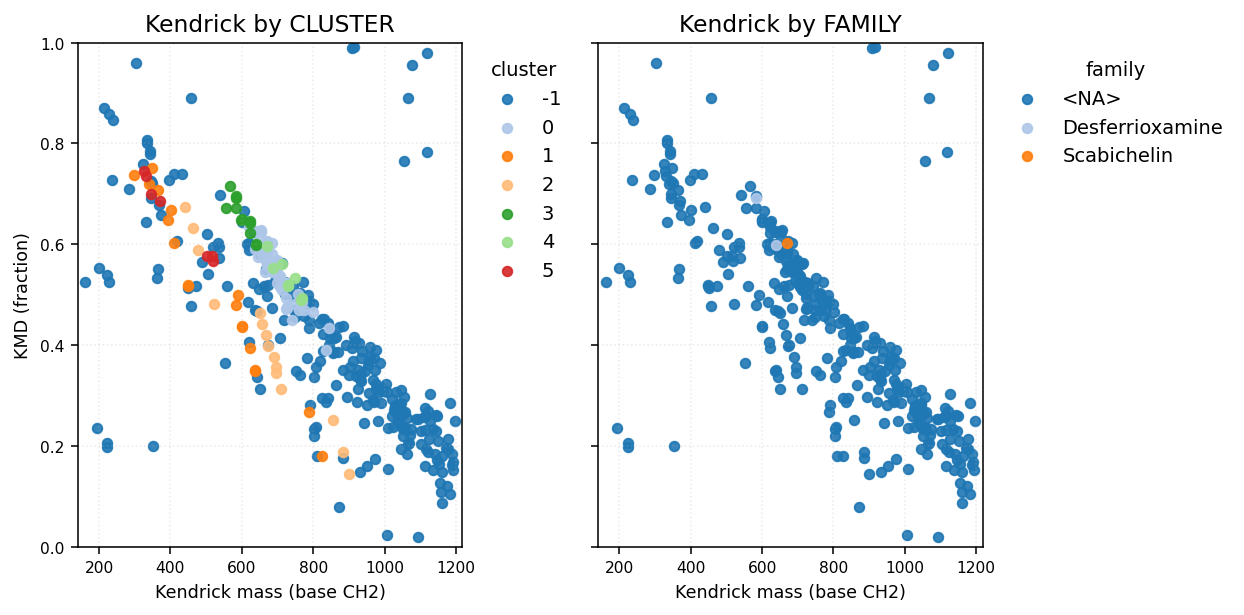

In [ ]:
# visualize the Kendrick plot for the clustered ions, colored by the annotations in the "known" column, and displaying the top 7 clusters in two separate panels.
cube.plot_kendrick(top_k_clusters=7,two_panels=True, label_col="known")

In [ ]:
# aggregate the ion images by the cluster labels in "mass_cluster", using mean aggregation, and store the aggregated images in obsm under the key "mass_cluster_agg". 
# This step will create new variables in the adata.obsm DataFrame with the key "mass_cluster_agg", where each variable corresponds to a cluster of ions and contains the aggregated ion image for that cluster. 
# The aggregation is performed by taking the mean of the ion images for the ions that belong to each cluster, and can be accessed and visualized using the appropriate functions in the MSICube class.
index = cube.aggregate_vars_by_label( label_col="mass_cluster" ,obsm_key="mass_cluster_agg",layer ="RAW" )

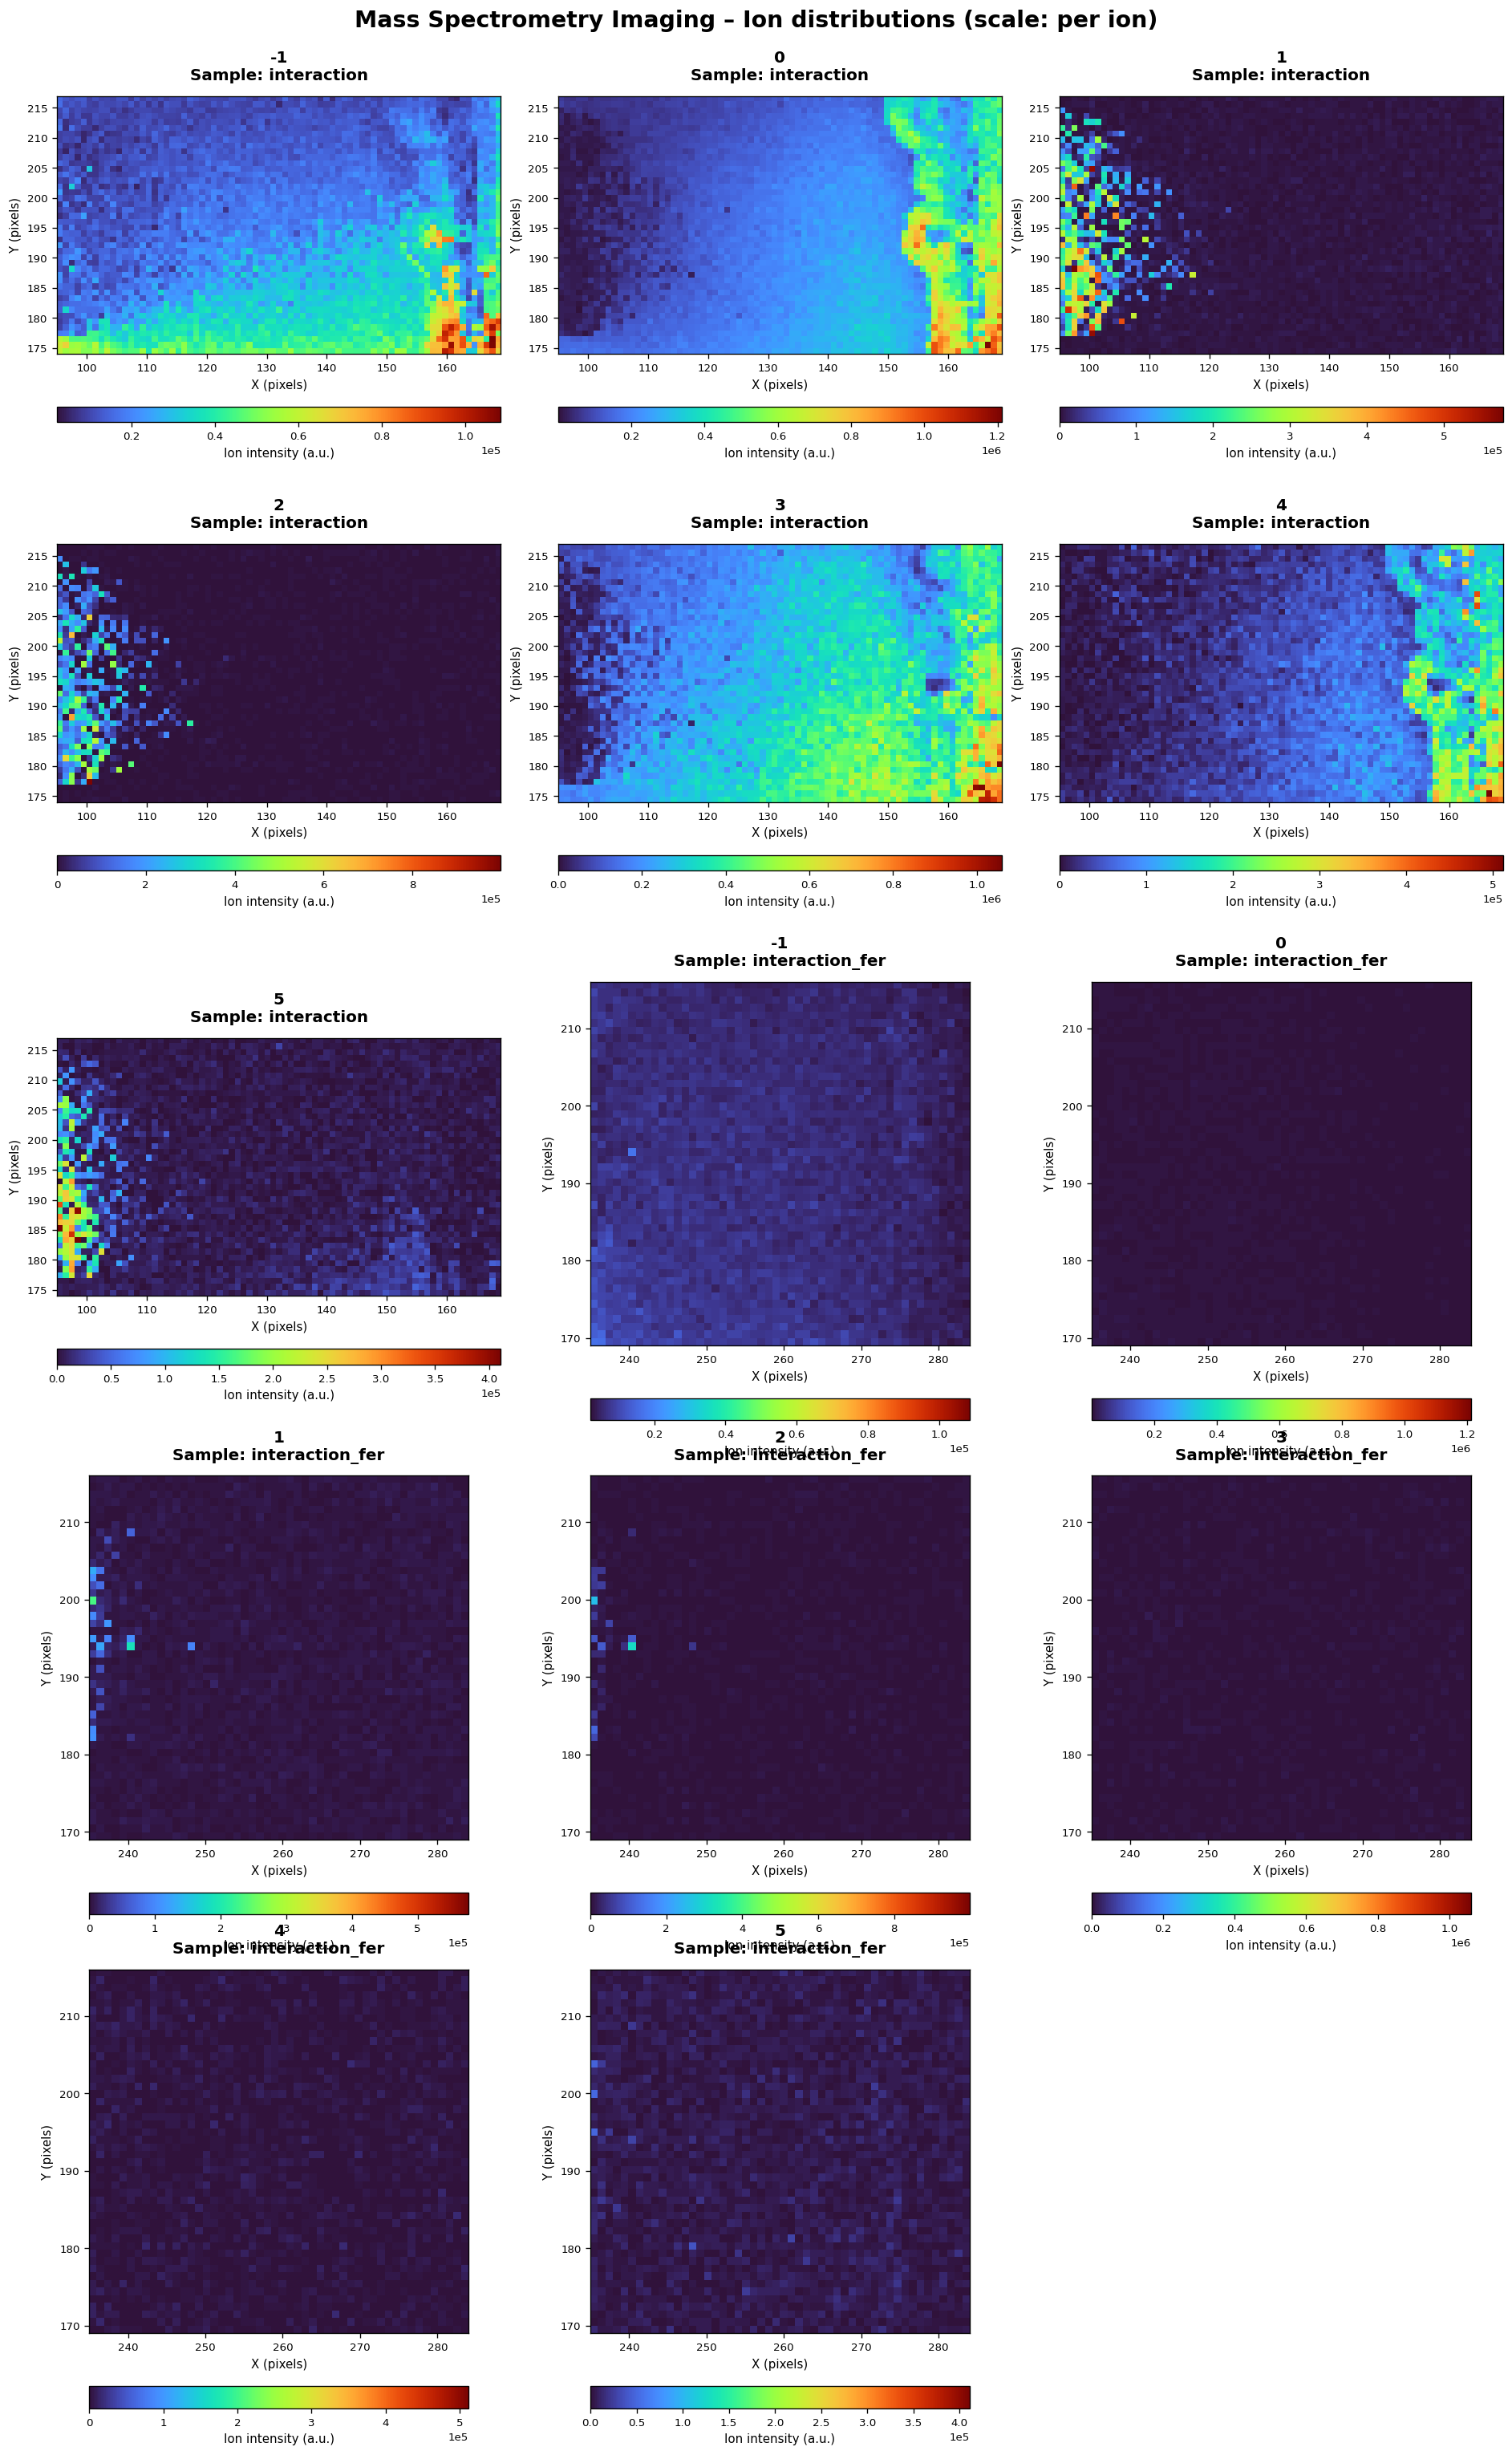

In [ ]:
# visualize the ion images for the clusters with labels "-1", "0", "1", "2", "3", "4", and "5" in the "mass_cluster_agg" obsm variable, using per ion scaling for the images.
cube.plot_ion_images(mz=["-1","0","1","2","3","4","5"],obsm_key="mass_cluster_agg",scale_mode ="per_ion")

In [ ]:
# subset the adata object to keep only the ions with annotations in the "known" column.
cube.adata.var[cube.adata.var["known"].notna()]

,mz,known,spatial_chaos_fold_change_control_max,spatial_chaos_fold_change_interaction_max,spatial_chaos_fold_change_FC_S,FC,mass_cluster,mdg_degree,mdg_wdegree
feature_id,,,,,,,,,
mz_605_498.2658,498.2658,unknown siderophore,0.195114,0.897933,4.602093,1,8,2,0.523250
mz_919_583.3438,583.3438,Desferrioxamine,0.153066,0.951835,6.218462,1,3,4,1.083234
mz_1211_639.3125,639.3125,Desferrioxamine,0.099893,0.959216,9.602475,1,3,6,1.112543
mz_1350_670.3511,670.3511,Scabichelin,0.043172,0.969217,22.450222,1,0,13,3.117179


In [40]:
pd.set_option('display.max_columns', None)

In [41]:
mn_col = ['src_pos', 'dst_pos', 'cosine_ion_cosine',
       'mz_i', 'mz_j', 'dm', 'cand_delta', 'cand_label','err',
       'dst_spatial_chaos_fold_change_control_max',
       'dst_spatial_chaos_fold_change_interaction_max',
       'dst_spatial_chaos_fold_change_FC_S', 'dst_mass_cluster',
       'dst_mdg_degree']

In [ ]:
#  direct_mass_neighbors allows you to retrieve the direct neighbors of a given ion in the mass difference graph, along with their cosine colocalization scores and the annotations of the mass differences between the central ion and its neighbors.

out = cube.direct_mass_neighbors("mz_605_498.2658",mass_uns_key = "mass_clustering",cosine_key = "ion_cosine")
out[mn_col]

,src_pos,dst_pos,cosine_ion_cosine,mz_i,mz_j,dm,cand_delta,cand_label,err,dst_spatial_chaos_fold_change_control_max,dst_spatial_chaos_fold_change_interaction_max,dst_spatial_chaos_fold_change_FC_S,dst_mass_cluster,dst_mdg_degree
0,75,81,0.797538,498.2658,514.2397,15.9739,15.973940,K-Na,0.000040,0.152086,0.940871,6.186436,8,4
1,75,92,0.632384,498.2658,540.2762,42.0104,42.010565,C+2 H+2 O+1,0.000165,0.135135,0.614476,4.547120,8,2


In [43]:
out = cube.direct_mass_neighbors("mz_919_583.3438",mass_uns_key = "mass_clustering",cosine_key = "ion_cosine")
out[mn_col]

,src_pos,dst_pos,cosine_ion_cosine,mz_i,mz_j,dm,cand_delta,cand_label,err,dst_spatial_chaos_fold_change_control_max,dst_spatial_chaos_fold_change_interaction_max,dst_spatial_chaos_fold_change_FC_S,dst_mass_cluster,dst_mdg_degree
0,107,132,0.971180,583.3438,623.3384,39.9946,39.994915,C+2 O+1,0.000315,0.116727,0.956047,8.190422,3,3
1,107,109,0.936319,583.3438,584.3475,1.0037,1.003350,13C-12C,0.000350,0.173068,0.892455,5.156668,3,2
2,107,113,0.828680,583.3438,599.3176,15.9738,15.973940,K-Na,0.000140,0.088520,0.956513,10.805609,3,6
3,107,103,0.730690,567.3488,583.3438,15.9950,15.994915,O+1,0.000085,0.166449,0.680519,4.088461,3,3


In [44]:
out = cube.direct_mass_neighbors("mz_1211_639.3125",mass_uns_key = "mass_clustering",cosine_key = "ion_cosine")
out[mn_col]

,src_pos,dst_pos,cosine_ion_cosine,mz_i,mz_j,dm,cand_delta,cand_label,err,dst_spatial_chaos_fold_change_control_max,dst_spatial_chaos_fold_change_interaction_max,dst_spatial_chaos_fold_change_FC_S,dst_mass_cluster,dst_mdg_degree
0,141,113,0.965515,599.3176,639.3125,39.9949,39.994915,C+2 O+1,0.000015,0.088520,0.956513,10.805609,3,6
1,141,143,0.960024,639.3125,640.3158,1.0033,1.003350,13C-12C,0.000050,0.100942,0.912695,9.041764,3,3
2,141,132,0.843206,623.3384,639.3125,15.9741,15.973940,K-Na,0.000160,0.116727,0.956047,8.190422,3,3
3,141,106,0.773479,583.3226,639.3125,55.9899,55.989829,C+2 O+2,0.000071,0.126171,0.813065,6.444177,3,5
4,141,131,0.771657,623.3174,639.3125,15.9951,15.994915,O+1,0.000185,0.154180,0.776243,5.034644,3,4
5,141,97,0.697354,555.2911,639.3125,84.0214,84.021129,C+4 H+4 O+2,0.000271,0.118538,0.706441,5.959620,3,4


In [45]:
out = cube.direct_mass_neighbors("mz_1350_670.3511",mass_uns_key = "mass_clustering",cosine_key = "ion_cosine")
out[mn_col]

,src_pos,dst_pos,cosine_ion_cosine,mz_i,mz_j,dm,cand_delta,cand_label,err,dst_spatial_chaos_fold_change_control_max,dst_spatial_chaos_fold_change_interaction_max,dst_spatial_chaos_fold_change_FC_S,dst_mass_cluster,dst_mdg_degree
0,168,172,0.992929,670.3511,671.3545,1.0034,1.003350,13C-12C,0.000050,0.108988,0.957338,8.783887,0,7
1,168,155,0.969894,654.3559,670.3511,15.9952,15.994915,O+1,0.000285,0.114168,0.923504,8.089002,0,7
2,168,198,0.935551,670.3511,698.3458,27.9947,27.994915,C+1 O+1,0.000215,0.175896,0.939035,5.338586,0,9
3,168,144,0.875191,640.3405,670.3511,30.0106,30.010565,C+1 H+2 O+1,0.000035,0.087948,0.829979,9.437173,0,8
4,168,154,0.862646,652.3408,670.3511,18.0103,18.010565,H+2 O+1,0.000265,0.154301,0.788534,5.110353,0,8
5,168,181,0.862229,670.3511,684.3666,14.0155,14.015650,C+1 H+2,0.000150,0.051712,0.788650,15.250936,0,8
6,168,184,0.854120,670.3511,686.3250,15.9739,15.973940,K-Na,0.000040,0.228717,0.974586,4.261109,0,18
7,168,128,0.820191,622.3300,670.3511,48.0211,48.021129,C+1 H+4 O+2,0.000029,0.122533,0.741123,6.048359,0,13
8,168,174,0.810353,670.3511,672.3580,2.0069,2.006700,13C2-12C2,0.000200,0.059361,0.741835,12.497069,0,3
9,168,207,0.759123,670.3511,708.3070,37.9559,37.955880,K-H,0.000020,0.188356,0.770856,4.092546,0,4


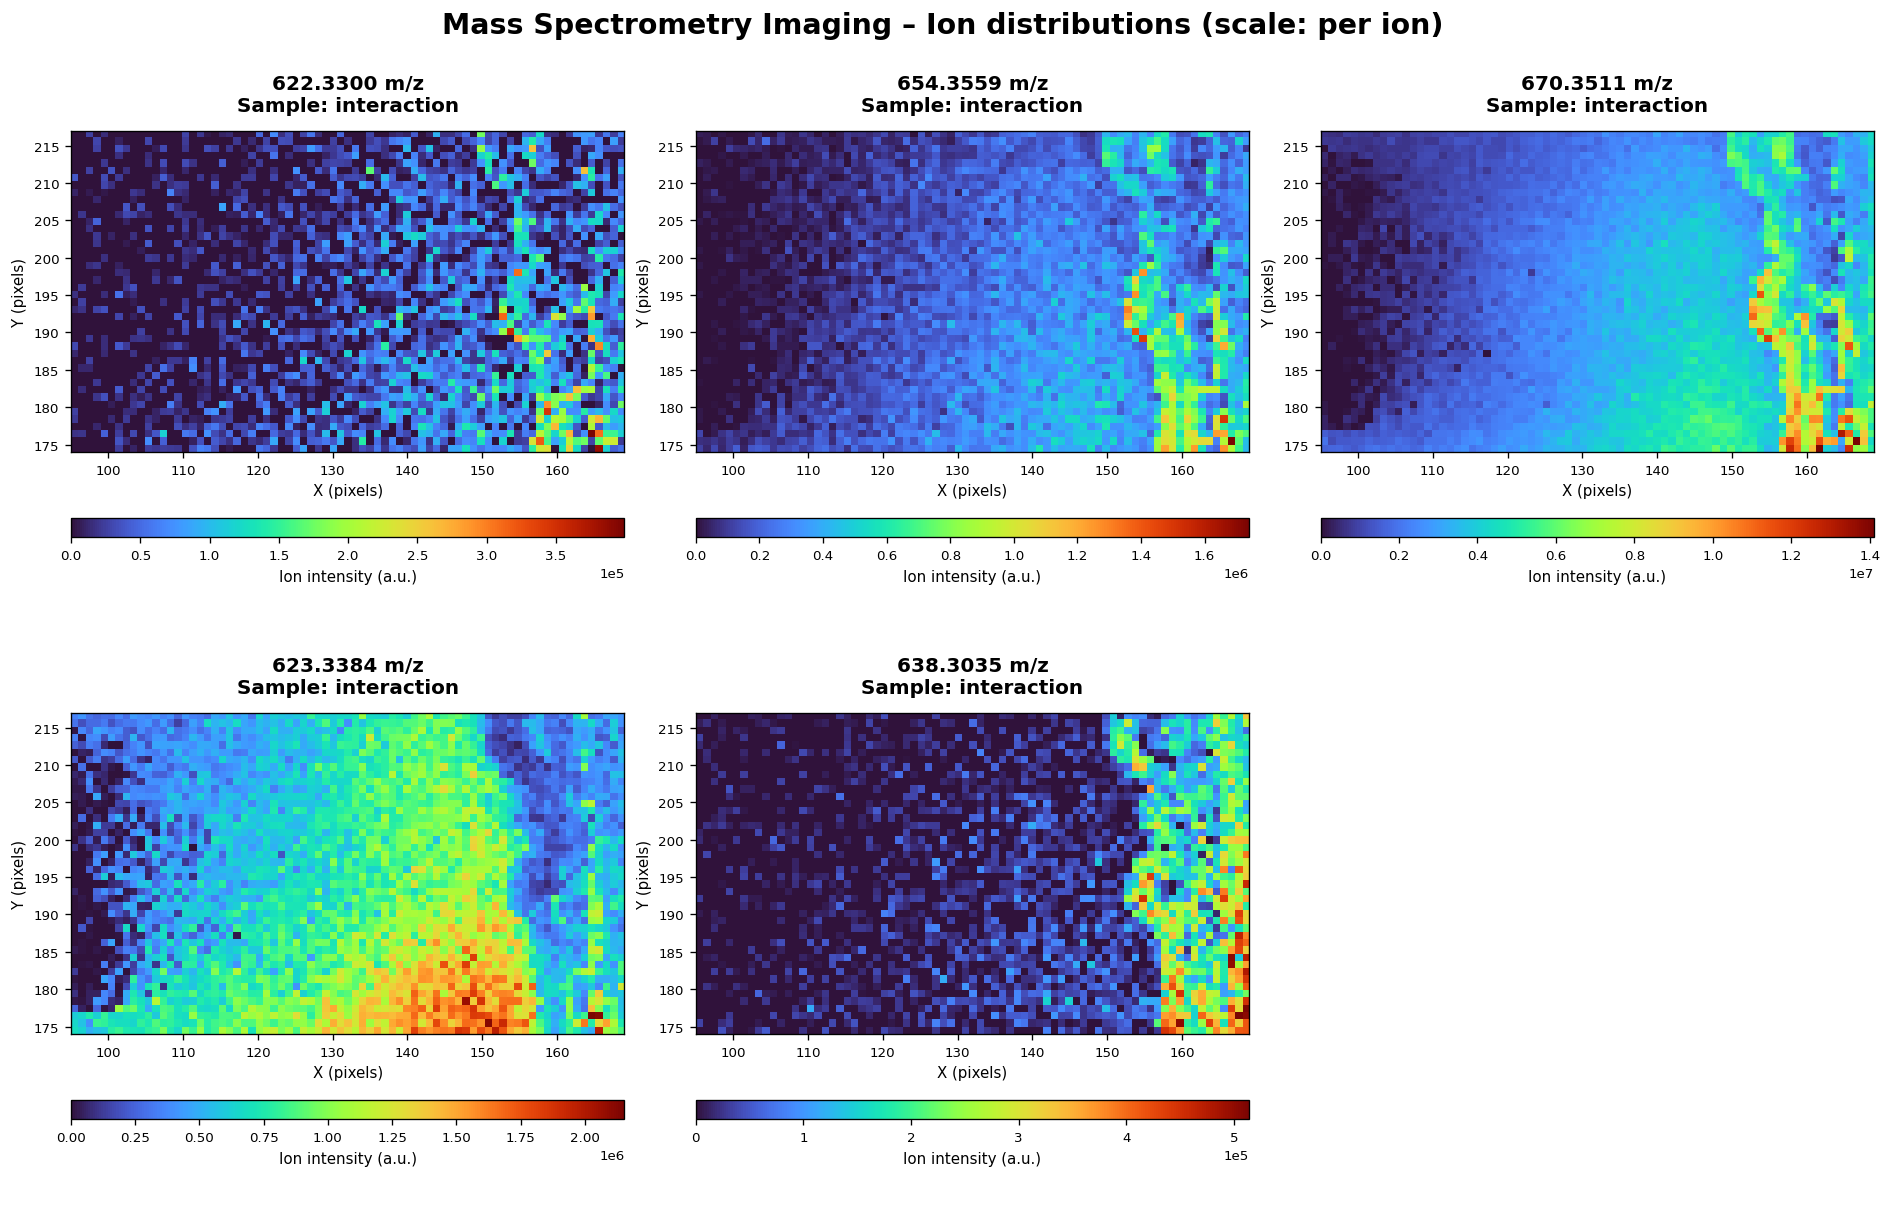

In [91]:
cube.plot_ion_images(mz=[622.3300,654.3559,670.3511	,623.3384,638.3035	],samples="interaction", scale_mode="per_ion")

In [ ]:
# The second part of the notebook shows how to compute ion ranking with rank_ions_groups_msi. 
# This function allows you to perform differential abundance analysis to identify the ions that are most differentially abundant between the "interaction" and "control" conditions, 
# based on their spatial chaos scores and other statistics. You can specify the parameters for the analysis, such as the method for ranking the ions (e.g., t-test, Wilcoxon test, logistic regression), 
# the number of top ions to return, whether to compute the area under the curve (AUC) for each ion, and whether to perform block bootstrapping for stability assessment.
#  The results will include a ranked list of ions, their associated statistics (e.g., p-values, fold changes, AUC), and stability metrics if block bootstrapping is performed. 
# You can then filter the results based on criteria such as fold change of spatial chaos scores to identify the most differentially abundant ions with significant changes in spatial chaos between the conditions.

In [ ]:
# reload the MSICube object to start with a clean slate for the ion ranking analysis.
from deltamsi.params.options import (RankIonsMSIParams,)
from deltamsi import MSICube
import numpy as np

cube = MSICube("/directory/containing/imzml/data")
cube.load()

cube.clip_or_mask_intensities(low=100000, low_action="move", result_layer="clip")
cube.compute_spatial_chaos_scores(obsm_key="spatial", sample_key="sample")

chaos = cube.adata.varm["spatial_chaos"]

mean_chaos = np.nanmax(chaos, axis=1)
keep_mask = mean_chaos >= 0.4

cube.adata = cube.adata[:, keep_mask].copy()

obs = cube.adata.obs
obs["condition"] = "control"
obs.loc[obs["sample"] == "interaction", "condition"] = "interaction"

fc_results = cube.compute_spatial_chaos_fold_change(
    groupby="condition",
    control_label="control",
    interaction_label="interaction"
)


INFO: MSICube initialized with 2 samples found.
INFO: AnnData loaded from /home/rlarocca20/msi_data/interaction/adata.h5ad (format=h5ad).


In [ ]:

mask = fc_results["FC_S"] > 2

cube.adata.var["FC"] = np.where(mask, "1", "0")

cube.adata = cube.adata[:, mask].copy()

,sample,condition
interaction_p0,interaction,interaction
interaction_p1,interaction,interaction
interaction_p2,interaction,interaction
interaction_p3,interaction,interaction
interaction_p4,interaction,interaction
...,...,...
interaction_fer_p2395,interaction_fer,control
interaction_fer_p2396,interaction_fer,control
interaction_fer_p2397,interaction_fer,control
interaction_fer_p2398,interaction_fer,control


In [ ]:
# define the parameters for ion ranking with rank_ions_groups_msi. This includes specifying the keys for the condition and sample annotations in the adata.obs DataFrame, 
# the name of the layer to use for the analysis (or None to use adata.X), 
# the method for ranking the ions (e.g., "t-test", "wilcoxon", "logreg", or "auto" to automatically select the method based on the data), 
# the number of top ions to return, whether to compute the area under the curve (AUC) for each ion, and whether to perform block bootstrapping for stability assessment
#  (if you have 1 vs 1 comparisons and want to assess within-image stability).
params = RankIonsMSIParams(
    condition_key="condition",
    sample_key="sample",
    group="interaction",
    reference="control",
    layer="RAW",                  # or None to use adata.X
    detection_threshold=0.0,
    method="auto",
    n_top=3000,
    compute_auc=True,
    # if you only have 1 vs 1 and want within-image stability (optional):
    block_bootstrap=True,
    block_size=25,
    n_boot=200,
)

In [ ]:
# compute the ion ranking using the specified parameters. 
# This will perform the statistical analysis to identify the ions that are most differentially abundant between the "interaction" and "control" conditions,
#  based on the specified method and parameters. The results will include the ranked list of ions, their associated statistics (e.g., p-values, fold changes, AUC), and stability metrics if block bootstrapping is performed.
out = cube.rank_ions_groups_msi(params = params)

In [ ]:
# you can then filter the results based on the fold change of spatial chaos scores (e.g., keep ions with fold change < 1.5 and log2 fold change > 2) 
# to identify the ions that are most differentially abundant and have a significant change in spatial chaos between the conditions.
out.loc[(out["spatial_chaos_fold_change_FC_S"]<1.5) & (out["log2fc"]>2)]

,ion,mz,log2fc_pixels,delta_detect_pixels,mean_pixels_group,mean_pixels_ref,pct_detect_pixels_group,pct_detect_pixels_ref,log2fc,delta_detect,mean_group,mean_ref,pct_detect_group,pct_detect_ref,auc,pval,pval_adj,stat_score,ci_low,ci_high,score,spatial_chaos_fold_change_FC_S
23,mz_476_456.0130,456.0130,5.264881,0.255492,1.248278e+06,32465.646484,0.674242,0.418750,5.264881,0.255492,1.248278e+06,32465.646484,0.674242,0.418750,0.719234,NaN,NaN,NaN,2.409444,6.905715,5.264881,1.321023
47,mz_1143_628.0810,628.0810,4.305753,0.125644,1.420659e+06,71833.843750,0.596061,0.470417,4.305753,0.125644,1.420659e+06,71833.843750,0.596061,0.470417,0.608685,NaN,NaN,NaN,0.998859,5.998897,4.305753,1.131168
58,mz_558_485.1088,485.1088,4.022332,0.177538,4.985219e+05,30679.039062,0.458788,0.281250,4.022332,0.177538,4.985219e+05,30679.039062,0.458788,0.281250,0.612761,NaN,NaN,NaN,-2.841331,6.361224,4.022332,1.434651
61,mz_1437_689.2193,689.2193,3.856509,0.406629,1.043164e+06,72015.796875,0.697879,0.291250,3.856509,0.406629,1.043164e+06,72015.796875,0.697879,0.291250,0.778821,NaN,NaN,NaN,2.357278,6.520235,3.856509,1.363676
62,mz_425_439.0356,439.0356,3.827402,0.155379,1.381271e+06,97300.718750,0.707879,0.552500,3.827402,0.155379,1.381271e+06,97300.718750,0.707879,0.552500,0.644779,NaN,NaN,NaN,0.897294,4.703090,3.827402,1.239617
66,mz_2184_859.3943,859.3943,3.671644,0.423636,3.820919e+05,29984.230469,0.940303,0.516667,3.671644,0.423636,3.820919e+05,29984.230469,0.940303,0.516667,0.938278,NaN,NaN,NaN,2.671368,5.127282,3.671644,1.229745
69,mz_472_455.0098,455.0098,3.600715,0.018409,4.026222e+06,331874.968750,0.864242,0.845833,3.600715,0.018409,4.026222e+06,331874.968750,0.864242,0.845833,0.604671,NaN,NaN,NaN,0.574829,5.095233,3.600715,1.006928
72,mz_1250_648.2462,648.2462,3.516620,0.494129,1.585585e+06,138542.046875,0.764545,0.270417,3.516620,0.494129,1.585585e+06,138542.046875,0.764545,0.270417,0.832286,NaN,NaN,NaN,2.326340,7.129484,3.516620,1.211787
83,mz_519_469.1347,469.1347,3.141976,0.160833,1.452181e+05,16450.972656,0.466667,0.305833,3.141976,0.160833,1.452181e+05,16450.972656,0.466667,0.305833,0.605612,NaN,NaN,NaN,-1.576394,4.632107,3.141976,1.215277
93,mz_626_507.0908,507.0908,2.976930,0.086250,6.413668e+04,8146.313477,0.300000,0.213750,2.976930,0.086250,6.413668e+04,8146.313477,0.300000,0.213750,0.554768,NaN,NaN,NaN,-1.805136,4.429876,2.976930,1.333136


In [174]:
out.loc[(out["spatial_chaos_fold_change_FC_S"]>2) & (out["log2fc"]<1)]

,ion,mz,log2fc_pixels,delta_detect_pixels,mean_pixels_group,mean_pixels_ref,pct_detect_pixels_group,pct_detect_pixels_ref,log2fc,delta_detect,mean_group,mean_ref,pct_detect_group,pct_detect_ref,auc,pval,pval_adj,stat_score,ci_low,ci_high,score,spatial_chaos_fold_change_FC_S
1403,mz_1738_764.3569,764.3569,0.954869,0.100492,11638.632812,6004.237305,0.274242,0.17375,0.954869,0.100492,11638.632812,6004.237305,0.274242,0.17375,0.554365,NaN,NaN,NaN,NaN,NaN,0.954869,2.033100
1406,mz_1831_786.3782,786.3782,0.953152,0.137727,12786.649414,6604.340332,0.322727,0.18500,0.953152,0.137727,12786.649414,6604.340332,0.322727,0.18500,0.571274,NaN,NaN,NaN,NaN,NaN,0.953152,2.124705
1433,mz_2206_866.2872,866.2872,0.941267,0.086742,13200.975586,6874.743164,0.284242,0.19750,0.941267,0.086742,13200.975586,6874.743164,0.284242,0.19750,0.550591,NaN,NaN,NaN,NaN,NaN,0.941267,2.138050
1470,mz_2094_841.2345,841.2345,0.926613,0.052765,7752.253906,4078.399902,0.201515,0.14875,0.926613,0.052765,7752.253906,4078.399902,0.201515,0.14875,0.527699,NaN,NaN,NaN,NaN,NaN,0.926613,2.110707
1711,mz_1661_747.1807,747.1807,0.788981,-0.005379,7859.690430,4548.817871,0.142121,0.14750,0.788981,-0.005379,7859.690430,4548.817871,0.142121,0.14750,0.498613,NaN,NaN,NaN,NaN,NaN,0.788981,2.006466


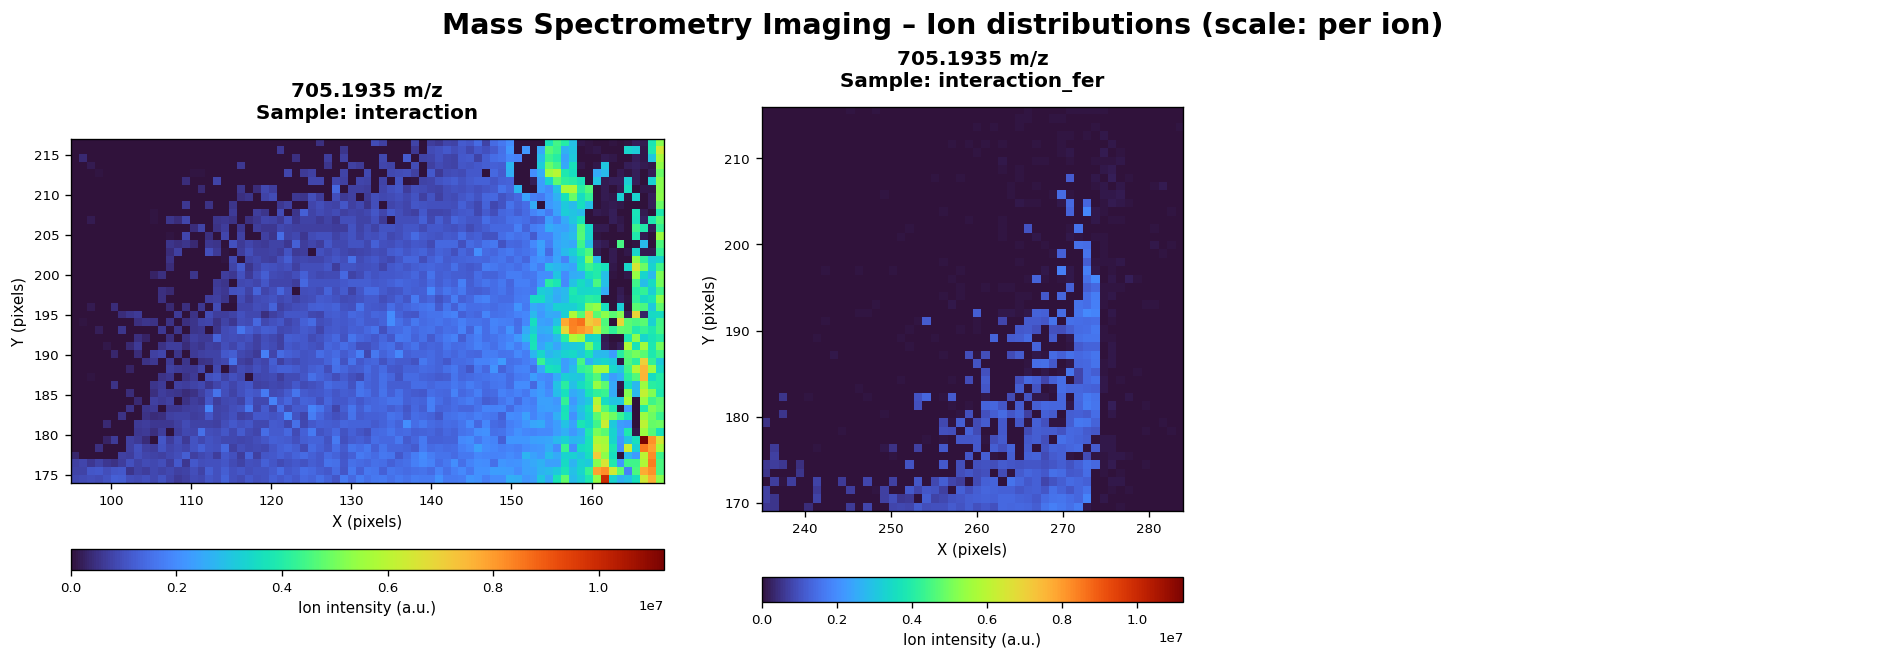

In [186]:
cube.plot_ion_images(mz=[705.1935], scale_mode="per_ion")